In [4]:
# Write a Python program to demonstrate image data augmentation techniques.

In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [6]:
(train,val,test),metadata=tfds.load(
    "tf_flowers",
    split=["train[:80%]","train[80%:90%]", "train[90%:]"],
    with_info=True,
    as_supervised=True
)

Dl Completed...: 100%|██████████| 1/1 [00:00<00:00, 70.85 url/s]


Dataset tf_flowers downloaded and prepared to C:\Users\lapto\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.


In [7]:
BATCH_SIZE=32
IMG_SIZE=(180,180)

In [8]:
def preprocess_input(image,label):
    image=tf.image.resize(image,IMG_SIZE)
    image=image/255.0
    return image,label

In [9]:
train=train.map(preprocess_input,num_parallel_calls=tf.data.AUTOTUNE)
val=val.map(preprocess_input,num_parallel_calls=tf.data.AUTOTUNE)
test=test.map(preprocess_input,num_parallel_calls=tf.data.AUTOTUNE)

In [10]:
augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.2),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2)
])

In [11]:
def plot(original,augmented):
    for i in range(len(original)):
        plt.subplot(2,len(original),i+1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, len(original), i+1+len(original))
        plt.imshow(augmented[i])
        plt.title("Augmented")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [12]:
num_samples=5
samples=[]

for image,_ in train.take(num_samples):
    samples.append(image.numpy())

    augmented_samples=augmentation(tf.convert_to_tensor(samples),training=True)

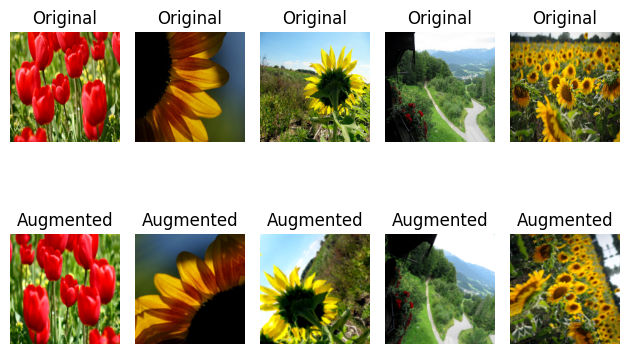

In [13]:
plot(samples, augmented_samples)